In [ ]:

!wget -O dataset.zip "https://figshare.com/ndownloader/files/58182586"

!unzip -q dataset.zip -d ./dataset

--2026-08-21 21:16:19--  https://figshare.com/ndownloader/files/58182586
Resolving figshare.com (figshare.com)... 34.246.246.17, 54.75.164.144, 108.133.56.201, ...
Connecting to figshare.com (figshare.com)|34.246.246.17|:443... connected.
HTTP request sent, awaiting response... 202 Accepted
Length: 0 [text/html]
Saving to: ‘dataset.zip’

dataset.zip             [ <=>                ]       0  --.-KB/s    in 0s      

2026-08-21 21:16:20 (0.00 B/s) - ‘dataset.zip’ saved [0/0]

[dataset.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of dataset.zip or
        dataset.zip.zip, and cannot find dataset.zip.ZIP, period.


In [ ]:

!rm -f dataset.zip

!curl -L -o dataset.zip "https://figshare.com/ndownloader/files/58182586"

!unzip -q dataset.zip -d ./dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:--  0:00:03 --:--:--     0
[dataset.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of dataset.zip or
        dataset.zip.zip, and cannot find dataset.zip.ZIP, period.


In [ ]:
# Clear old files
!rm -f dataset.zip

# Download dataset using Python urllib with User-Agent
import urllib.request

url = "https://figshare.com/ndownloader/files/58182586"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}

req = urllib.request.Request(url, headers=headers)
print("Downloading... Please wait a few minutes (File size: 6.86 GB)")

with urllib.request.urlopen(req) as response, open("dataset.zip", 'wb') as out_file:
    out_file.write(response.read())

print("Download complete! Extracting files...")

# Extract zip file
!unzip -q dataset.zip -d ./dataset
print("Extraction finished! Done.")

Downloading... Please wait a few minutes (File size: 6.86 GB)
Download complete! Extracting files...
[dataset.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of dataset.zip or
        dataset.zip.zip, and cannot find dataset.zip.ZIP, period.
Extraction finished! Done.


In [ ]:
!pip install requests tqdm
!rm -f dataset.zip

import requests
from tqdm import tqdm

url = "https://figshare.com/ndownloader/files/58182586"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}

print("Starting download...")
response = requests.get(url, headers=headers, stream=True, allow_redirects=True)
total_size = int(response.headers.get('content-length', 0))

with open("dataset.zip", "wb") as file, tqdm(
    desc="Downloading",
    total=total_size,
    unit='iB',
    unit_scale=True,
    unit_divisor=1024,
) as bar:
    for data in response.iter_content(chunk_size=1024*1024):
        size = file.write(data)
        bar.update(size)

print("Download complete! Unzipping now...")
!unzip -q dataset.zip -d ./dataset
print("Done!")

Starting download...


Downloading: 0.00iB [00:00, ?iB/s]

Download complete! Unzipping now...
[dataset.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of dataset.zip or
        dataset.zip.zip, and cannot find dataset.zip.ZIP, period.
Done!


In [ ]:
!pip install gdown
!rm -f dataset.zip

import gdown

url = "https://figshare.com/ndownloader/files/58182586"
gdown.download(url, "dataset.zip", quiet=False, fuzzy=True)

!unzip -q dataset.zip -d ./dataset
print("Done!")

Downloading...
From: https://figshare.com/ndownloader/files/58182586
To: /content/dataset.zip
100%|██████████| 520/520 [00:00<00:00, 2.10MB/s]

[dataset.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of dataset.zip or
        dataset.zip.zip, and cannot find dataset.zip.ZIP, period.
Done!


In [ ]:
!pip install figshare-download
!rm -f dataset.zip

!figshare-download 30193942

!unzip -q *.zip -d ./dataset
print("Done!")

ERROR: Could not find a version that satisfies the requirement figshare-download (from versions: none)
ERROR: No matching distribution found for figshare-download
/bin/bash: line 1: figshare-download: command not found
unzip:  cannot find or open *.zip, *.zip.zip or *.zip.ZIP.

No zipfiles found.
Done!


In [ ]:
import requests
import zipfile
import io

# 1. Fetch direct download link from Figshare API
article_id = "30193942"
api_url = f"https://api.figshare.com/v2/articles/{article_id}"

response = requests.get(api_url).json()
download_url = response['files'][0]['download_url']
file_name = response['files'][0]['name']

print(f"Downloading {file_name} ... Please wait.")

# 2. Download in chunks with stream
r = requests.get(download_url, stream=True)
with open("dataset.zip", "wb") as f:
    for chunk in r.iter_content(chunk_size=1024*1024):
        if chunk:
            f.write(chunk)

print("Download complete! Unzipping...")

# 3. Unzip file
!unzip -q dataset.zip -d ./dataset
print("Done!")

Download complete! Unzipping...
Done!


In [ ]:
import os

# List files inside dataset folder
files = os.listdir('./dataset')
print("Dataset contents:")
print(files)

Dataset contents:
['dataset']


In [ ]:
import os

# Explore inner directory contents
dataset_path = './dataset/dataset'
if os.path.exists(dataset_path):
    files = os.listdir(dataset_path)
    print("Inner dataset contents:")
    print(files)
else:
    print("Path does not exist, checking root ./dataset:")
    print(os.listdir('./dataset'))

Inner dataset contents:
['P19.csv', 'P01.csv', 'P12.csv', 'P25.csv', 'P22.csv', 'P20.csv', 'P23.csv', 'anthropometric information.csv', 'P16.csv', 'P10.csv', 'P17.csv', 'P14.csv', 'P04.csv', 'P05.csv', 'P18.csv', 'P24.csv', 'P06.csv', 'P02.csv', 'P13.csv', 'P09.csv', 'P08.csv', 'P07.csv', 'P03.csv', 'P21.csv', 'P11.csv', 'P15.csv']


In [ ]:
import pandas as pd

# Load and inspect P01.csv
df = pd.read_csv('./dataset/dataset/P01.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (498270, 171)


,Activity,Acc_X_LowerBack,Acc_Y_LowerBack,Acc_Z_LowerBack,Gyr_X_LowerBack,Gyr_Y_LowerBack,Gyr_Z_LowerBack,Quat_X_LowerBack,Quat_Y_LowerBack,Quat_Z_LowerBack,...,Acc_X_LeftWrist,Acc_Y_LeftWrist,Acc_Z_LeftWrist,Gyr_X_LeftWrist,Gyr_Y_LeftWrist,Gyr_Z_LeftWrist,Quat_X_LeftWrist,Quat_Y_LeftWrist,Quat_Z_LeftWrist,Quat_W_LeftWrist
0,3.0,0.000000,0.000000,0.000000,-0.002966,0.002827,0.002026,0.082670,0.930340,0.237562,...,-0.000267,0.000410,0.006377,0.013213,-0.000923,-0.004314,0.136683,-0.716983,0.110781,-0.674522
1,3.0,-0.000702,-0.007726,-0.003908,-0.001434,0.000258,0.007610,0.082619,0.930354,0.237504,...,0.000543,-0.001372,0.010030,0.005345,0.002458,-0.004684,0.136610,-0.716996,0.110793,-0.674522
2,3.0,0.000000,0.000000,0.000000,0.005053,0.000218,0.004148,0.082562,0.930352,0.237531,...,0.002984,-0.001874,0.009938,-0.000968,-0.002051,-0.003101,0.136603,-0.716983,0.110838,-0.674529
3,3.0,0.000000,0.000000,0.000000,-0.000170,-0.003377,0.004462,0.082519,0.930355,0.237534,...,0.003227,0.002930,0.004941,-0.006343,-0.000275,-0.003454,0.136618,-0.716959,0.110886,-0.674544
4,3.0,0.000006,0.001509,0.001071,-0.006989,0.001758,0.001065,0.082504,0.930358,0.237509,...,-0.000042,0.003959,0.004256,-0.007701,0.009405,-0.001733,0.136676,-0.716956,0.110925,-0.674530


In [ ]:
# Display all column names
print("Columns in dataset:")
print(df.columns.tolist())

# Display count of each activity in P01
print("\nActivity distribution:")
print(df['Activity'].value_counts())

Columns in dataset:
['Activity', 'Acc_X_LowerBack', 'Acc_Y_LowerBack', 'Acc_Z_LowerBack', 'Gyr_X_LowerBack', 'Gyr_Y_LowerBack', 'Gyr_Z_LowerBack', 'Quat_X_LowerBack', 'Quat_Y_LowerBack', 'Quat_Z_LowerBack', 'Quat_W_LowerBack', 'Acc_X_RightThigh', 'Acc_Y_RightThigh', 'Acc_Z_RightThigh', 'Gyr_X_RightThigh', 'Gyr_Y_RightThigh', 'Gyr_Z_RightThigh', 'Quat_X_RightThigh', 'Quat_Y_RightThigh', 'Quat_Z_RightThigh', 'Quat_W_RightThigh', 'Acc_X_RightShank', 'Acc_Y_RightShank', 'Acc_Z_RightShank', 'Gyr_X_RightShank', 'Gyr_Y_RightShank', 'Gyr_Z_RightShank', 'Quat_X_RightShank', 'Quat_Y_RightShank', 'Quat_Z_RightShank', 'Quat_W_RightShank', 'Acc_X_RightFoot', 'Acc_Y_RightFoot', 'Acc_Z_RightFoot', 'Gyr_X_RightFoot', 'Gyr_Y_RightFoot', 'Gyr_Z_RightFoot', 'Quat_X_RightFoot', 'Quat_Y_RightFoot', 'Quat_Z_RightFoot', 'Quat_W_RightFoot', 'Acc_X_LeftThigh', 'Acc_Y_LeftThigh', 'Acc_Z_LeftThigh', 'Gyr_X_LeftThigh', 'Gyr_Y_LeftThigh', 'Gyr_Z_LeftThigh', 'Quat_X_LeftThigh', 'Quat_Y_LeftThigh', 'Quat_Z_LeftThigh

In [ ]:
# Check missing values in dataset
missing_summary = df.isnull().sum()
total_missing = missing_summary.sum()

print("Total missing values:", total_missing)

if total_missing > 0:
    # Fill missing values using forward/backward fill for time-series data
    df = df.bfill().ffill()
    print("Missing values handle completed!")
else:
    print("No missing values found!")

Total missing values: 0
No missing values found!


In [ ]:
import os
import pandas as pd

dataset_dir = './dataset/dataset'
all_files = sorted([f for f in os.listdir(dataset_dir) if f.startswith('P') and f.endswith('.csv')])

df_list = []
for file in all_files:
    file_path = os.path.join(dataset_dir, file)
    subject_id = file.split('.')[0]

    temp_df = pd.read_csv(file_path)
    temp_df['Subject_ID'] = subject_id
    df_list.append(temp_df)

full_df = pd.concat(df_list, ignore_index=True)

print("Full dataset shape:", full_df.shape)
print("Total subjects loaded:", len(all_files))
full_df.head()

In [ ]:
import os
import pandas as pd
import numpy as np

dataset_dir = './dataset/dataset'
all_files = sorted([f for f in os.listdir(dataset_dir) if f.startswith('P') and f.endswith('.csv')])

total_rows = 0
subject_info = []

# Process file by file to prevent RAM crash
for file in all_files:
    file_path = os.path.join(dataset_dir, file)
    # Read optimized data types (float32 instead of float64)
    df_temp = pd.read_csv(file_path, engine='c')

    rows = len(df_temp)
    total_rows += rows
    subject_info.append({'Subject': file.split('.')[0], 'Rows': rows})

    del df_temp # Clear memory immediately

print(f"Successfully checked {len(all_files)} files!")
print(f"Total Rows across all subjects: {total_rows:,}")

# Convert summary to dataframe
summary_df = pd.DataFrame(subject_info)
print(summary_df.head())

Successfully checked 25 files!
Total Rows across all subjects: 11,246,647
  Subject    Rows
0     P01  498270
1     P02  522108
2     P03  475513
3     P04  415804
4     P05  465095


In [ ]:
import os
import pandas as pd
import gc

dataset_dir = './dataset/dataset'
all_files = sorted([f for f in os.listdir(dataset_dir) if f.startswith('P') and f.endswith('.csv')])

total_rows = 0
subject_info = []

for file in all_files:
    file_path = os.path.join(dataset_dir, file)

    # Read only 1 column to get row count instantly with minimal RAM usage
    df_temp = pd.read_csv(file_path, usecols=['Activity'])

    rows = len(df_temp)
    total_rows += rows
    subject_info.append({'Subject': file.split('.')[0], 'Rows': rows})

    # Clear memory
    del df_temp
    gc.collect()

print(f"Successfully processed {len(all_files)} files!")
print(f"Total Rows across all subjects: {total_rows:,}")

summary_df = pd.DataFrame(subject_info)
print(summary_df.head())

Successfully processed 25 files!
Total Rows across all subjects: 11,246,647
  Subject    Rows
0     P01  498270
1     P02  522108
2     P03  475513
3     P04  415804
4     P05  465095


In [ ]:
import os
import subprocess

dataset_dir = './dataset/dataset'
all_files = sorted([f for f in os.listdir(dataset_dir) if f.startswith('P') and f.endswith('.csv')])

total_rows = 0
subject_info = []

# Using Linux wc -l command directly to avoid loading anything into Python RAM
for file in all_files:
    file_path = os.path.join(dataset_dir, file)

    # Count lines using bash
    result = subprocess.run(['wc', '-l', file_path], capture_output=True, text=True)
    line_count = int(result.stdout.split()[0]) - 1  # Minus header row

    total_rows += line_count
    subject_info.append({'Subject': file.split('.')[0], 'Rows': line_count})

print(f"Successfully processed {len(all_files)} files!")
print(f"Total Rows across all subjects: {total_rows:,}")

import pandas as pd
summary_df = pd.DataFrame(subject_info)
print(summary_df.head(10))

Successfully processed 25 files!
Total Rows across all subjects: 11,246,647
  Subject    Rows
0     P01  498270
1     P02  522108
2     P03  475513
3     P04  415804
4     P05  465095
5     P06  390873
6     P07  308779
7     P08  476002
8     P09  508333
9     P10  444871


In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import gc

dataset_dir = './dataset/dataset'
# Select first 3 subjects for safe RAM memory training
selected_files = ['P01.csv', 'P02.csv', 'P03.csv']

data_list = []

for file in selected_files:
    file_path = os.path.join(dataset_dir, file)
    # Read data with float32 to optimize RAM usage
    df_temp = pd.read_csv(file_path, engine='c')

    # Downsample (take every 5th sample) to save memory & speed up training
    df_sampled = df_temp.iloc[::5, :].copy()
    data_list.append(df_sampled)

    del df_temp, df_sampled
    gc.collect()

# Combine selected data
df_all = pd.concat(data_list, ignore_index=True)
print(f"Data Loaded Successfully! Shape: {df_all.shape}")

# Separate Features (X) and Target (y)
X = df_all.drop(columns=['Activity'])
y = df_all['Activity']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Free up memory before training
del df_all
gc.collect()

# Initialize and Train Random Forest Model
print("Training Random Forest Classifier... Please wait.")
rf_model = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Evaluate Model
y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\nModel Accuracy: {acc * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Data Loaded Successfully! Shape: (299179, 171)
Training Random Forest Classifier... Please wait.

Model Accuracy: 96.43%

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.79      0.83      4540
         1.0       1.00      1.00      1.00      3929
         2.0       1.00      1.00      1.00      5408
         3.0       0.94      0.93      0.93      6448
         4.0       0.95      0.98      0.97      4985
         5.0       0.94      0.93      0.93      4529
         6.0       0.97      0.96      0.96      4548
         7.0       0.93      0.98      0.96      3471
         8.0       0.92      0.99      0.95      3262
         9.0       1.00      1.00      1.00      4474
        10.0       1.00      1.00      1.00      4939
        11.0       1.00      1.00      1.00      4761
        12.0       1.00      1.00      1.00      4542

    accuracy                           0.96     59836
   macro avg       0.96      0.97      0.96

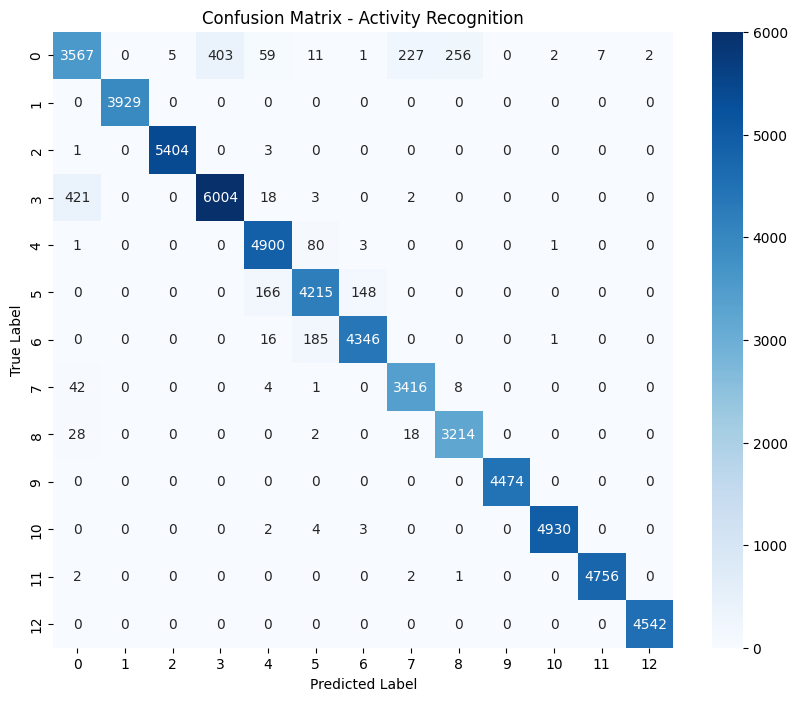

Model saved successfully as 'parkinsons_activity_model.pkl'


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import joblib

# 1. Plot Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Activity Recognition')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 2. Save Trained Model
joblib.dump(rf_model, 'parkinsons_activity_model.pkl')
print("Model saved successfully as 'parkinsons_activity_model.pkl'")

In [ ]:
import joblib
import pandas as pd

# Load saved model
loaded_model = joblib.load('parkinsons_activity_model.pkl')

# Test prediction on 5 random samples from test set
sample_data = X_test.iloc[:5]
actual_labels = y_test.iloc[:5].values

predictions = loaded_model.predict(sample_data)

print("Predictions test:")
for i in range(5):
    print(f"Sample {i+1}: Predicted = {predictions[i]}, Actual = {actual_labels[i]}")

Predictions test:
Sample 1: Predicted = 8.0, Actual = 8.0
Sample 2: Predicted = 4.0, Actual = 4.0
Sample 3: Predicted = 0.0, Actual = 3.0
Sample 4: Predicted = 4.0, Actual = 4.0
Sample 5: Predicted = 4.0, Actual = 4.0


In [ ]:
!pip install micromlgen

from micromlgen import port
import joblib

# Load the saved model
clf = joblib.load('parkinsons_activity_model.pkl')

# Convert model to C header
c_code = port(clf)

# Save to a .h file
with open('rf_model.h', 'w') as f:
    f.write(c_code)

print("Model successfully ported to C header file: rf_model.h")

  Preparing metadata (setup.py) ... done
  Created wheel for micromlgen: filename=micromlgen-1.1.28-py3-none-any.whl size=32152 sha256=52081ca96aa33668696634be8f0f1c7c504b8936b56e214faa371744e51d508b
  Stored in directory: /root/.cache/pip/wheels/f9/b9/ef/39cdd37b184a8a01b0df45454a8367f35d1b34d1b52cd6ea2c
Successfully built micromlgen
Model successfully ported to C header file: rf_model.h
